# 02 · LDA 토픽 모델

전처리·토큰화된 뉴스(`news_tokenized.pkl`)로 gensim LDA를 학습한다.
사전/코퍼스 구성 → 토픽 수 탐색(coherence) → 학습 → 토픽 키워드/문서분포 → pyLDAvis.

무거운 로직은 `src/topic_model.py`에 있고, 여기서는 import해서 분석/시각화만 한다.

In [1]:
# 셋업
import sys; sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

import config
from src import preprocess as pp
from src import topic_model as tm

config.set_korean_font()

df = pp.load_processed("news_tokenized")
token_lists = df["nouns"].tolist()
print("문서 수:", len(token_lists))

문서 수: 20079


## 1. 사전 & 코퍼스 구성

`filter_extremes`로 희귀어(5개 문서 미만)와 과빈출어(전체의 50% 초과)를 제거한다.
과빈출어 제거는 `지역·사회·지원` 같은 복지 보도자료 상투어가 모든 토픽을 덮는 것을 완화한다.

In [2]:
dictionary, corpus = tm.build_corpus(token_lists, no_below=5, no_above=0.3)
print("사전 크기(단어):", len(dictionary))
print("코퍼스 문서 수:", len(corpus))

사전 크기(단어): 7742
코퍼스 문서 수: 20079


## 2. 토픽 수 탐색 — Coherence (c_v)

토픽 수 k를 4~12까지 바꿔가며 일관성 점수를 비교한다. (수 분 소요)
※ c_v는 k=2~3 같은 trivial 해를 과대평가하는 경향이 있어 탐색을 4부터 시작한다.

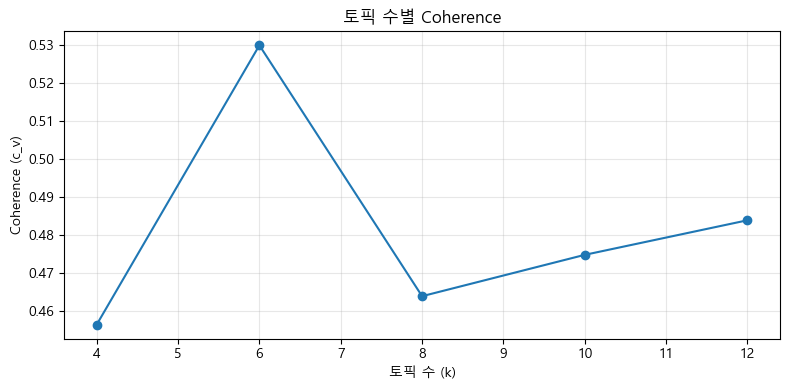

,num_topics,coherence
0,4,0.456363
1,6,0.530007
2,8,0.463865
3,10,0.474766
4,12,0.483880


In [3]:
coh_df = tm.compute_coherence(dictionary, corpus, token_lists,
                              start=4, limit=13, step=2, passes=5)
coh_df.to_csv(config.TABLE_DIR / "02_coherence.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coh_df["num_topics"], coh_df["coherence"], marker="o")
ax.set_xlabel("토픽 수 (k)")
ax.set_ylabel("Coherence (c_v)")
ax.set_title("토픽 수별 Coherence")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIG_DIR / "02_coherence.png", dpi=150)
plt.show()

coh_df

## 3. LDA 학습

Coherence가 가장 높은 k로 최종 모델을 학습한다. (필요시 `BEST_K`를 수동 지정)

In [4]:
BEST_K = int(coh_df.loc[coh_df["coherence"].idxmax(), "num_topics"])
print("선택된 토픽 수 k =", BEST_K)

lda = tm.train_lda(dictionary, corpus, num_topics=BEST_K, passes=15)

선택된 토픽 수 k = 6


## 4. 토픽별 키워드

In [5]:
topics_df = tm.topics_dataframe(lda, topn=12)
topics_df.to_csv(config.TABLE_DIR / "02_topics.csv", index=False, encoding="utf-8-sig")
for _, r in topics_df.iterrows():
    print(f"[토픽 {r['topic']}] {r['keywords']}")

[토픽 0] 이웃, 사랑, 김장, 회장, 기탁, 독거노인, 계층, 김치, 봉사, 기부, 취약, 직원
[토픽 1] 국가, 통합, 공단, 의료, 국민, 건강, 치매, 노인, 관리, 보훈, 평가, 요양
[토픽 2] 안전, 복지, 대응, 한파, 체계, 노인, 대책, 폭염, 시민, 구축, 생활, 본격
[토픽 3] 취약, 계층, 독거노인, 어르신, 가구, 복지, 사회보장, 생활, 충북, 장애인, 방문, 가정
[토픽 4] 복지, 문화, 주거, 광주, 센터, 기관, 부문, 단체, 울산, 서울, 한국, 대구
[토픽 5] 가구, 고독사, 고립, 예방, 복지, 협약, 안부, 위험, 위기, 발굴, 업무, 확인


## 5. 문서별 대표 토픽 분포

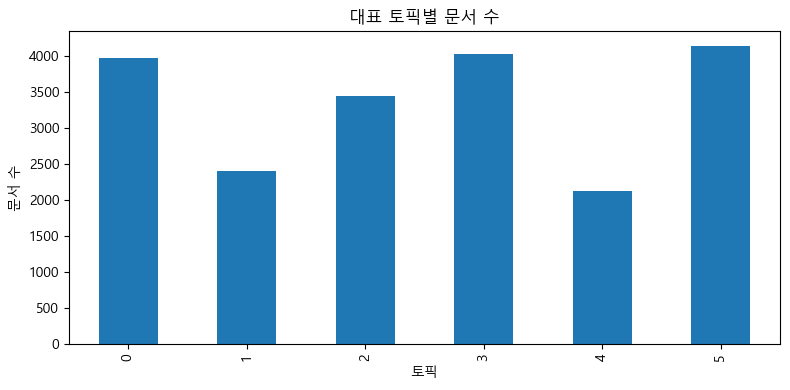

dominant_topic
0    3964
1    2401
2    3443
3    4023
4    2118
5    4130
Name: count, dtype: int64

In [6]:
dom = tm.dominant_topics(lda, corpus)
df_dom = pd.concat([df.reset_index(drop=True), dom], axis=1)

dist = df_dom["dominant_topic"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
dist.plot.bar(ax=ax)
ax.set_xlabel("토픽")
ax.set_ylabel("문서 수")
ax.set_title("대표 토픽별 문서 수")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "02_topic_doc_dist.png", dpi=150)
plt.show()

dist

## 6. pyLDAvis 시각화

토픽 간 거리·단어 비중을 인터랙티브하게 살펴본다. HTML로도 저장한다.

In [7]:
import pyLDAvis

vis = tm.make_pyldavis(lda, corpus, dictionary)
pyLDAvis.save_html(vis, str(config.FIG_DIR / "02_ldavis.html"))
pyLDAvis.display(vis)

## 메모

- 토픽이 잘 안 갈리면: `no_above`를 더 낮추거나(예: 0.3), `config.STOP_WORDS`에 상투어를 추가하고
  `news_tokenized.pkl`를 재생성한 뒤 다시 학습한다.
- `BEST_K`는 coherence 최댓값으로 자동 선택하되, 해석 가능성을 보고 수동 조정해도 된다.